Hidden Layer:  
- `get_hidden_state`: return the hidden state value at a given time step
- `set_hidden_state`: Update the state at a time step after forward pass calculation
- `activate`: forward pass calculation: $s_t = W \cdot a_{t-1} + U \cdot x_t + b$ where $a_t = tanh(s_t)$
- `calculate_deltas_per_step`: compute gradients of `W` and `b`, the recurrent weight and bias matrices  
$\frac{\partial L_{t}}{\partial b} = \frac{\partial L_{t}}{\partial s_{t}} \cdot \frac{\partial s_{t}}{\partial b} = \frac{\partial L_{t}}{\partial s_{t}} \cdot \frac{\partial(W \cdot a_{t-1} + U \cdot x_{t} + b)}{\partial b} = \frac{\partial L_{t}}{\partial s_{t}} \cdot 1 = \frac{\partial L_{t}}{\partial s_{t}}$  
$\frac{\partial L_{t}}{\partial W} = \frac{\partial L_{t}}{\partial s_{t}} \cdot \frac{\partial s_{t}}{\partial W} = \frac{\partial L_{t}}{\partial s_{t}} \cdot \frac{\partial(W \cdot a_{t-1} + U \cdot x_{t} + b)}{\partial W} = \frac{\partial L_{t}}{\partial s_{t}} \cdot a_{t-1}$
- `update_weights_and_bias`: update the parameters using gradient  
$W = V - \alpha \cdot \frac{\partial L_t}{\partial W}$  
$b = b - \alpha \cdot \frac{\partial L_t}{\partial b}$

Output Layer:  

![Description](imgs/hidden_state.png)

In [91]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

def gmm_loss(mean, std, weights, ys):
    normals = torch.distributions.Normal(mean, std)
    
    log_probs = normals.log_prob(ys)
    log_probs = log_probs + torch.log(weights)
    log_probs = torch.logsumexp(log_probs, dim=1)
    
    loss = -log_probs.mean()

    return loss

class MDRNN(nn.Module):
    def __init__(self, latents, actions, hiddens, gaussians):
        super().__init__()
        self.latents = latents # size of latent tensor
        self.actions = actions # size of action tensor
        self.hiddens = hiddens # size of hidden tensor
        self.gaussians = gaussians # number of distributions 

        self.rnn = nn.LSTM(latents + actions, hiddens)
        self.gmm_linear = nn.Linear(hiddens, (2 * latents + 1) * gaussians + 2)

    def forward(self, actions, latents):
        seq_len, bs = actions.size(0), actions.size(1)
        
        ins = torch.cat([actions, latents], dim=-1)
        outs, _ = self.rnn(ins)
        gmm_outs = self.gmm_linear(outs)

        stride = self.gaussians * self.latents

        mus = gmm_outs[:, :, :stride]
        mus = mus.view(seq_len, bs, self.gaussians, self.latents)

        sigmas = gmm_outs[:, :, stride:2 * stride]
        sigmas = sigmas.view(seq_len, bs, self.gaussians, self.latents)
        sigmas = torch.exp(sigmas)

        pi = gmm_outs[:, :, 2 * stride: 2 * stride + self.gaussians]
        pi = pi.view(seq_len, bs, self.gaussians)
        logpi = F.log_softmax(pi, dim=-1)

        rs = gmm_outs[:, :, -2]

        ds = gmm_outs[:, :, -1]
        
        return mus, sigmas, logpi, rs, ds

In [99]:
# observations = torch.tensor(np.array(observations))
# actions = torch.tensor(np.array(actions))
# rewards = torch.tensor(np.array(rewards))
# dones = torch.tensor(np.array(dones))
# next_states = torch.tensor(np.array(next_states))

tensors_dict = {
    "observations" : observations,
    "actions" : actions,
    "rewards" : rewards,
    "dones" : dones,
    "next_states" : next_states,
}

torch.save(tensors_dict, 'data/observations.pt')

In [1]:
from VAE import VAE

VAE_load = VAE()
VAE_load.load_state_dict(torch.load("models/CarRacing_VAE_20_epochs", weights_only=True))

ModuleNotFoundError: No module named 'VAE'

In [93]:
observations = torch.tensor(np.array(observations))
actions = torch.tensor(np.array(actions))
rewards = torch.tensor(np.array(rewards))
dones = torch.tensor(np.array(dones))
next_states = torch.tensor(np.array(next_states))

observations_loader = DataLoader(observations, batch_size=32, shuffle=False)
actions_loader = DataLoader(actions, batch_size=32, shuffle=False)
rewards_loader = DataLoader(rewards, batch_size=32, shuffle=False)
dones_loader = DataLoader(dones, batch_size=32, shuffle=False)
next_states_loader = DataLoader(next_states, batch_size=32, shuffle=False)

vae = VAE()
rnn = MDRNN(32, 3, 64, 32)
optimizer = torch.optim.Adam(rnn.parameters(), lr=1e-3)
n_ep = 20

for epoch in range(n_ep):
    total_loss = 0.0 
    for o, a, r, d, n in zip(observations_loader, actions_loader, rewards_loader, dones_loader, next_states_loader):
        optimizer.zero_grad()
        print(a)
        mu, logstd, _ = vae(o.float() / 256)
        var = torch.exp(logstd)
        latents = torch.distributions.Normal(mu, var).sample()        
        
        mus, sigmas, logpi, rs, ds = rnn(a, latents)
        loss = loss_fn(data.float() / 256, decoded, mu, logstd)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(loader.dataset)
    print(
        "Epoch {}/{}: loss={:.4f}".format(epoch + 1, n_ep, epoch_loss)
    )

tensor([[-0.6729,  0.2717,  0.0188],
        [ 0.4241,  0.7213,  0.0785],
        [-0.6391,  0.5876,  0.9804],
        [ 0.0791,  0.0874,  0.8627],
        [-0.7658,  0.1660,  0.6359],
        [ 0.3836,  0.7183,  0.2910],
        [ 0.1858,  0.0920,  0.9549],
        [-0.1093,  0.6191,  0.4468],
        [ 0.2459,  0.6613,  0.8069],
        [-0.3797,  0.2091,  0.0733],
        [-0.6513,  0.0599,  0.5392],
        [-0.7347,  0.2238,  0.9577],
        [-0.1891,  0.7292,  0.9055],
        [-0.3147,  0.2628,  0.6755],
        [-0.5395,  0.7038,  0.2197],
        [ 0.4808,  0.3806,  0.2780],
        [ 0.3484,  0.2086,  0.5119],
        [ 0.9907,  0.6334,  0.4770],
        [ 0.2146,  0.5136,  0.3106],
        [ 0.6651,  0.5741,  0.7173],
        [ 0.9749,  0.9384,  0.2369],
        [ 0.5409,  0.9975,  0.6958],
        [ 0.8979,  0.4610,  0.5810],
        [ 0.7171,  0.4808,  0.6623],
        [-0.8473,  0.5734,  0.9931],
        [-0.7655,  0.2805,  0.2906],
        [-0.8003,  0.5094,  0.7298],
 

IndexError: too many indices for tensor of dimension 2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


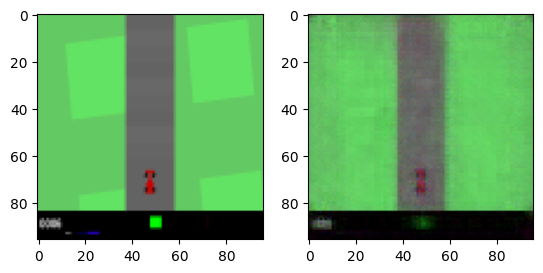

In [85]:
img = observations[75].float() / 256
mu, logstd, decoded = VAE_load(img.view(1, 96, 96, 3))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(img)
ax2.imshow(decoded.view(96, 96, 3).detach().cpu() , cmap='viridis');

In [2]:
import torch
o = torch.load('../data/observations.pt')

C:\Users\Pranav\AppData\Local\Temp\ipykernel_6400\2498798963.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  o = torch.load('../data/observations.pt')


In [16]:
o

AttributeError: 'dict' object has no attribute 'shape'